# Project Walkthrough: Breaking BAKMM-IoD and Building FSL-AKE-IoD

**work completed till date**

This notebook explains our whole project from start to finish, so that someone who has not read the paper can
still follow it. We tried to write it the way we would explain it to a classmate:

* what the original protocol (BAKMM-IoD) does,
* **how** we looked for problems (our method),
* every **drawback** we found, each with a small piece of code that shows it happening,
* the **reasoning** behind every part of our own protocol (FSL-AKE-IoD),
* how our **first version (v1)** turned out to be broken too, and how **version 2 (v2)** fixes it,
* what v2 still cannot do, what it costs, and what is left to do.

Every result in this notebook is produced by the code below it, not typed by hand. If you run all cells
(Kernel → Restart & Run All), you should see the same outcomes. The random values will differ, but the
conclusions will not.

> **How to read it:** each section has a short explanation, then code, then a "What we see" paragraph
> that explains the output. If you only have five minutes, read Section 1 and the summary in Section 12.

## Contents
1. The problem in one page
2. Background: the words we use
3. BAKMM-IoD in brief
4. Our method: how we looked for problems
5. The drawbacks of BAKMM-IoD (A0–A5, E, C)
6. Design reasoning: what our protocol has to achieve, and why each piece is there
7. FSL-AKE-IoD v1 (our first draft)
8. How we broke our own v1
9. FSL-AKE-IoD v2: the fixes and the reasons behind them
10. What v2 still cannot do (the honest limitations)
11. Proving every piece is needed (ablation) and what it costs
12. Formal verification status, summary of all work, next steps
13. Glossary

## 1. The problem in one page

Drones (**DE**) send data to ground stations (**ES**), which pass it to cloud servers (**CS**) that store it on a
blockchain. Before a drone sends anything, the drone and the ES must **authenticate each other** ("are you really who
you say?") and agree on a fresh **session key (SK)** to encrypt the data. This step is called an **AKE**
(Authenticated Key Exchange).

The paper we were assigned, **BAKMM-IoD** (Wazid et al., *J. Syst. Archit.* 160 (2025) 103365), proposes a very cheap
AKE that uses only hashing and XOR. It claims to resist 14 kinds of attack.

**What we found:** the protocol's secrets never change. As a result:

1. If someone captures **one** drone, they can decrypt **every conversation that drone ever had** and will ever have.
2. Losing **one** packet, or flipping **one** bit of it, can lock a drone out **forever**.
3. Several equations in the paper are misprinted, so the protocol as written does not actually work.

**What we built:** FSL-AKE-IoD, a 2-message protocol in which the shared key changes after every session, so
capturing a drone does not expose its past. Our first version still had bugs that could lock drones out; we found
them by attacking our own design and fixed them in **v2**. v2 is also cheaper than BAKMM-IoD.

In [1]:
# Setup: our code lives in proposed/code
import sys, os, copy
sys.path.insert(0, os.path.join(os.getcwd(), "proposed", "code"))
import pandas as pd
pd.set_option("display.max_colwidth", 120)

from common import Clock, AuthError, h, xor, rnd, size_bits, reset_hash_counter, hashes, ID_BYTES
import bakmm_iod as B            # BAKMM-IoD as implemented (with the paper's typo corrected)
import bakmm_literal as L        # BAKMM-IoD exactly as printed in the paper
import proposed_fslake as V1     # our first version (v1), unchanged from the draft
import fslake as F               # our fixed version (v2)
print("modules loaded")

modules loaded


**What we see:** the four implementations load. Throughout the notebook, `Clock` is a simulated clock (so timestamps
are reproducible), and `h(...)` is SHA-256 over the concatenated inputs. `h` also counts how many times it is called,
which we use later to measure cost.

## 2. Background: the words we use

| Term | Meaning in this project |
|---|---|
| **Session key (SK)** | A fresh key agreed in each login and used to encrypt that session's data |
| **Long-term secret** | A secret stored on the device for its whole life (in BAKMM-IoD: RID and MS) |
| **Pseudonym (TID)** | A temporary identity sent instead of the real ID, so eavesdroppers cannot tell which drone is talking |
| **Forward secrecy** | If a device is compromised **today**, the sessions from **yesterday** stay secret |
| **Replay attack** | The attacker records a message and sends it again later |
| **De-synchronisation (de-sync)** | Drone and ES end up with different ideas of the current TID or key, so the drone can never log in again |
| **Timestamp window ΔT** | A message is accepted only if its timestamp is within ΔT seconds of the receiver's clock (we use ΔT = 2 s) |
| **XOR masking** | Hiding a value V by sending V ⊕ M. Anyone who knows the mask M gets V back with one XOR |

**Threat model.** We use exactly the attacker that the BAKMM-IoD paper itself allows (§3.2 of the paper):

* **Dolev–Yao:** the attacker controls the network. It can read, change, drop, delay and replay any message.
* **Canetti–Krawczyk (CK):** the attacker can additionally learn session keys and temporary values of some sessions.
* **Drone capture:** the attacker can physically capture a drone and read its memory ("advanced power analysis").

This point matters: we never gave the attacker more power than the paper grants it. When an attack needs an extra
assumption, we say so and mark it **CONDITIONAL**.

## 3. BAKMM-IoD in brief

**Registration (offline).** The Registration Authority (RA) gives the drone
$\{TID, RID_{DE}, TC_{DE}, MS\}$, where $MS$ is the master secret shared with the ground station. The ES stores
$(TID \rightarrow RID_{DE}, MS)$ for every drone. **RID and MS never change.**

**Authentication (3 messages).** Let $A = h(TC_{DE}\|rs_1\|MS\|T_1)$ and $B = h(RID_{ES}\|TC_{ES}\|rs_2\|MS\|T_2)$
(drone and ES random values).

$$
\begin{aligned}
MSG_1 &= \{TID,\; M_1 = h(RID_{DE}\|MS\|T_1)\oplus A,\; M_2 = h(A\|RID_{DE}\|T_1),\; T_1\}\\
MSG_2 &= \{M_3 = h(RID_{DE}\|MS\|T_2)\oplus B,\; M_4 = h(SK\|T_1\|T_2\|RID_{DE}),\; M_5 = TID_{new}\oplus h(A\|RID_{DE}\|T_2),\; T_2\}\\
MSG_3 &= \{M_6 = h(SK\|T_3),\; T_3\}\qquad SK = h(A\|B\|T_1\|T_2\|RID_{DE}\|MS)
\end{aligned}
$$

Let us first check that an honest run works.

In [2]:
clock = Clock()
ra, es, de = B.setup(clock)
tr, sk_drone, sk_station = B.run_session(de, es, clock)
print("MSG1 fields:", list(tr["MSG1"]), " MSG2 fields:", list(tr["MSG2"]), " MSG3 fields:", list(tr["MSG3"]))
print("drone and ES derived the same key:", sk_drone == sk_station)
print("drone memory after the session:", {k: v.hex()[:10] + "..." for k, v in de.mem.items()})

MSG1 fields: ['TID', 'M1', 'M2', 'T1']  MSG2 fields: ['M3', 'M4', 'M5', 'T2']  MSG3 fields: ['M6', 'T3']
drone and ES derived the same key: True
drone memory after the session: {'TID': '694ea2cb2d...', 'RID': '19d8e54033...', 'TC': '614896da2e...', 'MS': '06154d32b7...'}


**What we see:** an honest session works, and both sides get the same SK. Note what the drone keeps in memory:
TID, RID, TC and MS. Remember those four values, because the whole first attack is about them.

## 4. Our method: how we looked for problems

We did not want to write "we think this is insecure". We wanted to **show** it. So for every claim we did four things:

1. **Read the paper exactly.** The PDF's text layer drops the math symbols, so we rendered the pages as images and
   copied the equations from those. This is how we found misprints that everyone else had silently "fixed".
2. **Implement the protocol in Python** and check that honest runs work (1000 sessions in a row).
3. **Write each attack as a small program** that does only what the threat model in Section 2 allows. If the program
   recovers a key, or leaves a drone unable to log in, the flaw is real.
4. **Label the result:** CONFIRMED (works under the paper's own assumptions), CONDITIONAL (needs one extra assumption,
   which we name), or REFUTED.

We applied **the same method to our own protocol**. That is how we found that our first draft (v1) was broken
(Section 8). Finally we put every expected result into an automated test file (`tests/test_protocols.py`,
50 tests) so anyone can re-check everything with one command: `python -m pytest tests -q`.

## 5. The drawbacks of BAKMM-IoD

### A0: The paper's two session-key formulas do not match (specification error)

**What the paper says.** On the ES side (step AKDDE2) the key is $h(A\|B\|T_1\|T_2\|RID\|MS)$. On the drone side
(step AKDDE3, and again in Table 5) it is $h(A\|B\|RID\|T_1\|T_2\|MS)$. The inputs are the same, but **the order is
different**, and a hash of a different order is a completely different value.

**How we found it.** While copying the equations from the page images. Our `LiteralDrone` class uses the order
exactly as printed for the drone.

In [3]:
agree = 0
for _ in range(1000):
    c = Clock(); ra = B.RA(); es = B.GroundStation(ra.register_es(c), c)
    cred = ra.register_drone(c); es.enroll(cred)
    try:
        _, a, b = B.run_session(L.LiteralDrone(cred, c), es, c); agree += (a == b)
    except AuthError:
        pass
print(f"sessions where the printed formulas agree: {agree}/1000")

sessions where the printed formulas agree: 0/1000


**What we see:** 0/1000. The protocol, exactly as printed, never completes. All the other code and models in this
repository (and our teammates' notebooks) had quietly used one order on both sides. From here on we use the
corrected version, because we want to test the *design*, not the typo.

### A1: Capturing one drone reveals all its past and future session keys (major)

**The paper's claim (Proposition 5):** a captured drone gives the attacker "solely the session key and registration
data of this particular drone".

**Our reasoning.** Look at the masks in $M_1$ and $M_3$: $h(RID\|MS\|T_1)$ and $h(RID\|MS\|T_2)$. They depend only on
RID and MS, which **never change**, and on the timestamps, which are **sent in plain text**. So once the attacker has
RID and MS from the captured drone, it can rebuild every mask of every session it has recorded, remove the masks with
XOR, and recompute every SK. The random values $rs_1$, $rs_2$ and the credential TC do not help, because A and B are
recovered *as whole values* from $M_1$ and $M_3$.

**Test:** the attacker records 5 sessions, then captures the drone.

In [4]:
clock = Clock(); ra, es, de = B.setup(clock)
recorded, real_keys = [], []
for _ in range(5):                                    # attacker only eavesdrops
    tr, sk, _ = B.run_session(de, es, clock); recorded.append(tr); real_keys.append(sk); clock.advance(60)

stolen = copy.deepcopy(de.mem)                        # drone captured: memory read out
RID, MS = stolen["RID"], stolen["MS"]

for i, tr in enumerate(recorded):
    m1, m2 = tr["MSG1"], tr["MSG2"]
    A  = xor(m1["M1"], h(RID, MS, m1["T1"]))          # remove mask from M1
    Bv = xor(m2["M3"], h(RID, MS, m2["T2"]))          # remove mask from M3
    SK = h(A, Bv, m1["T1"], m2["T2"], RID, MS)
    tid_new = xor(m2["M5"], h(A, RID, m2["T2"])[:ID_BYTES])
    print(f"session {i+1}: recovered SK correct = {SK == real_keys[i]},  TID {m1['TID'].hex()[:8]} -> next TID {tid_new.hex()[:8]}")

session 1: recovered SK correct = True,  TID 06c78dce -> next TID e5f9a829
session 2: recovered SK correct = True,  TID e5f9a829 -> next TID 9843d857
session 3: recovered SK correct = True,  TID 9843d857 -> next TID 8d9874c5
session 4: recovered SK correct = True,  TID 8d9874c5 -> next TID 69b2dcf1
session 5: recovered SK correct = True,  TID 69b2dcf1 -> next TID 754a587f


**What we see:** every past session key is recovered, and each session's "next TID" is exactly the TID used in the
following session, so the attacker can also **link the whole history of the drone**. The same trick works for future
sessions. This is the opposite of forward secrecy. It contradicts Proposition 5, the paper's feature list (ASFF8 drone
capture, ASFF13 untraceability), and §3.2, which says the design "supports forward secrecy".

**Why the paper's formal check missed it.** The paper's Scyther model declares `xor` as a plain function symbol, with
no rule that $(V\oplus M)\oplus M = V$. In that model the attacker can never remove a mask, so the tool cannot see this
attack at all. We wrote a corrected model (`bakmm_auth_compromise.spdl`), but it could not be run here because
Scyther is not installed.

### A2: A stolen ground-station database lets anyone pose as any drone (CONDITIONAL)

**Reasoning.** The ES stores $(RID, MS)$ for every drone *in the clear*. Those two values are all you need to build
valid messages. The drone's credential $TC_{DE}$ is part of $A$, but the ES never checks it (it does not even store it).

In [5]:
clock = Clock(); ra, es, de = B.setup(clock)
B.run_session(de, es, clock); clock.advance(10)
TID, rec = next(iter(es.db.items()))                  # attacker copies the ES table
print("fields stored per drone at the ES:", sorted(rec))
fake = B.Drone(dict(TID=TID, RID=rec["RID"], MS=rec["MS"], TC=rnd(32)), clock)   # TC is pure garbage
_, sk_attacker, sk_es = B.run_session(fake, es, clock)
print("ES accepted the fake drone and shares its key with the attacker:", sk_attacker == sk_es)

fields stored per drone at the ES: ['MS', 'RID']
ES accepted the fake drone and shares its key with the attacker: True


**What we see:** the forged drone is accepted even though its TC is random. We mark this **CONDITIONAL**, because the
paper's Proposition 4 assumes access control stops anyone from reading the database. The part "TC is never checked" is
unconditional.

### A3: One lost message locks the drone out forever

**Reasoning.** In every session the ES gives the drone a new pseudonym $TID_{new}$ and replaces the old one. The paper
never says **when** the ES replaces it, so we tested both readings:
* ES switches when it **sends** MSG2. If MSG2 is lost, the drone still uses the old TID, which the ES has forgotten.
* ES switches only after **receiving** MSG3. The drone has already switched, so if MSG3 is lost, the ES still expects
  the old TID.

The ES keeps only **one** TID per drone, so there is no way back.

In [6]:
def drone_is_locked_out(de, es, clock, tries=3):
    for _ in range(tries):
        clock.advance(60)
        try:
            _, a, b = B.run_session(de, es, clock)
            if a == b: return False
        except AuthError:
            pass
    return True

for policy in ("on_send", "on_confirm"):
    for dropped in ("MSG2", "MSG3"):
        clock = Clock(); _, es, de = B.setup(clock, policy)
        B.run_session(de, es, clock, drop=dropped)       # attacker deletes one message
        print(f"ES switches TID {policy:10s} | attacker drops {dropped}: drone locked out = {drone_is_locked_out(de, es, clock)}")

ES switches TID on_send    | attacker drops MSG2: drone locked out = True
ES switches TID on_send    | attacker drops MSG3: drone locked out = False
ES switches TID on_confirm | attacker drops MSG2: drone locked out = False
ES switches TID on_confirm | attacker drops MSG3: drone locked out = True


**What we see:** whichever reading you choose, there is one message whose loss locks the drone out permanently. It
would need to be registered again by the RA. The attacker only has to delete one packet, which the Dolev–Yao model
explicitly allows. Our teammates' `Attack_log.ipynb` predicted the MSG3 case; we confirmed it and found the MSG2 case too.

### A4: Replaying MSG1 within the time window is accepted

**Reasoning.** The paper's only defence against replay (Proposition 1) is the timestamp check $|T - T^*| \le \Delta T$.
A copy sent again *inside* the window passes that check, and nothing remembers that the message was already seen.

In [7]:
for policy in ("on_confirm", "on_send"):
    clock = Clock(); _, es, de = B.setup(clock, policy)
    m1 = de.start(); m2 = es.respond(m1)
    try:
        es.respond(copy.deepcopy(m1)); accepted = True        # replay, same second
    except AuthError:
        accepted = False
    print(f"{policy:10s}: replayed MSG1 accepted = {accepted}")

on_confirm: replayed MSG1 accepted = True
on_send   : replayed MSG1 accepted = False


**What we see:** it depends on the unspecified policy. If the ES switches TID only on MSG3 (`on_confirm`), the replay
is accepted, and in our implementation it even overwrites the genuine session, which then fails and locks the drone
out. If the ES switches on MSG2, the old TID is already gone, so the replay is rejected. Verdict: acceptance is
CONFIRMED under one reading; the lock-out is CONDITIONAL.

### A5 (new, found by us): flipping one bit of M5 locks the drone out

**How we found it.** We wrote a general "man-in-the-middle" test that changes **each field** of each message, one at
a time, and checks whether the receiver notices. For BAKMM-IoD, one field was not noticed: $M_5$.

**Reasoning.** $M_4 = h(SK\|T_1\|T_2\|RID)$ is the check value the drone verifies, but it does not include $M_5$. So
the attacker can flip bits in $M_5$. The drone then decodes a *wrong* new TID and saves it, while the ES saves the
right one. Both sides think the session succeeded.

In [8]:
clock = Clock(); _, es, de = B.setup(clock)
m1 = de.start(); clock.advance(); m2 = es.respond(m1); clock.advance()
m2 = dict(m2); m2["M5"] = bytes([m2["M5"][0] ^ 1]) + m2["M5"][1:]   # attacker flips ONE bit
m3 = de.finish(m2); clock.advance(); es.confirm(m3)                 # no error on either side
print("session reported as successful on both sides")
print("drone locked out afterwards:", drone_is_locked_out(de, es, clock))

session reported as successful on both sides
drone locked out afterwards: True


**What we see:** no error anywhere, yet the drone can never log in again. This contradicts Proposition 2 ("it is not
feasible for the adversary to make any changes in the transmitted messages"). It was not in our original draft; we
found it only because we tested every field systematically.

### E and C: Other errors in the paper

* **E: the ES–cloud key-management phase does not work as printed.** The first message hashes $TC_{ES}\|RS_1$ while
  the second uses $RS_1\|TC_{ES}$, so the cloud server's check fails. In addition, the ES is told to recover the cloud's
  new pseudonym using $RS_2$, a random value that only the cloud server knows. We implemented it literally to confirm both.
* **C: arithmetic in §7.2.** The paper prints $|MSG_3| = 2880$ bits and a total of "704 + 800 + 288 = 1782". The sum is
  actually 1792 (which is what the paper's own Table 9 says), so both are typos. Minor, but worth reporting.

In [9]:
for E1, E4, label in ((False, False, "corrected"), (True, False, "printed m1/m2 order"), (False, True, "printed TIN recovery (needs RS2)")):
    c = Clock(); e_cred, cs_cred = L.RAKM.register(c)
    es_, cs_ = L.ESInitiator(e_cred, c, E1, E4), L.CSResponder(cs_cred, c)
    results = []
    try:
        for s in range(2):
            a, b = L.run_km(es_, cs_, c); c.advance(10); results.append(f"session {s+1} ok")
    except AuthError as ex:
        results.append(f"session {len(results)+1} FAILS ({ex})")
    print(f"{label:34s}: {', '.join(results)}")
print("Sec. 7.2 total:", 704 + 800 + 288, "bits")

corrected                         : session 1 ok, session 2 ok
printed m1/m2 order               : session 1 FAILS (CS: m2 mismatch)
printed TIN recovery (needs RS2)  : session 1 ok, session 2 FAILS (CS: unknown TIN (desynchronised))
Sec. 7.2 total: 1792 bits


### Summary of the drawbacks

| Id | Drawback | Verdict | Root cause |
|---|---|---|---|
| A0 | the two printed SK formulas differ | CONFIRMED (typo) | specification error |
| A1 | capture reveals all past and future keys, links all TIDs | **CONFIRMED** | secrets never change; masks are recomputable |
| A2 | stolen ES table lets anyone impersonate a drone | CONDITIONAL | verifier table stored in the clear; TC never checked |
| A3 | one dropped message causes permanent lock-out | **CONFIRMED** | only one TID kept, no recovery path |
| A4 | replay inside ΔT | CONFIRMED / CONDITIONAL | timestamps only, no memory of seen messages |
| A5 | one flipped bit of M5 causes lock-out | **CONFIRMED (new)** | M5 not covered by the check value M4 |
| E, C | ES–CS phase broken as printed; arithmetic typos | CONFIRMED | specification errors |

The common thread: **static long-term secrets** (A1, A2) and **fragile, one-way state updates** (A3, A4, A5).

## 6. Design reasoning: what our protocol must achieve, and why each piece is there

We turned each drawback into a **design goal**, then chose the cheapest mechanism that achieves it. Staying cheap
matters: drones have small batteries, so we allowed ourselves only hash functions (no public-key crypto), and we
wanted to beat BAKMM-IoD's 8 hash operations and 3 messages.

| Goal | Drawback it answers | Mechanism we chose | Why this and not something else |
|---|---|---|---|
| Past sessions stay secret after capture | A1 | **M1: key evolution** $K \leftarrow h(K\|SK)$ after every session | A hash is one-way: from today's $K$ you cannot compute yesterday's. The textbook alternative (Diffie–Hellman with elliptic curves) gives more protection but costs about 3× more on the drone. |
| Past sessions cannot be linked | A1 (TID chain) | **M2: silent pseudonym update** $TID \leftarrow h(TID\|SK)$ | Both sides can compute the next TID themselves, so it never has to be sent. BAKMM sends it (in M5), which is exactly what leaked it and what allowed A5. |
| A lost message must not lock out | A3, A5 | **M3: ES keeps the old record too** | If the drone did not receive the reply, it still has the old key, and the ES still recognises it. |
| Replays inside ΔT are rejected | A4 | **M4: replay cache** of $(TID, T_1, N_1)$ | Timestamps alone cannot stop a copy inside the window. The cache only has to hold entries for ΔT, so it stays small. |
| A stolen ES database is useless | A2 | **M5: masked verifier** $C = K\oplus h(X_{ES}\|TID)$, with $X_{ES}$ in a secure chip (TPM/HSM) | The database never contains $K$ itself. Without $X_{ES}$, $C$ looks like random bytes. |
| Be cheaper | cost | **M6: two messages** | The drone authenticates in MSG1 and the ES in MSG2, which is enough for both sides to authenticate each other. |

**Key idea to remember:** every session both sides do $K \leftarrow h(K\|SK)$ and then **forget the old K**.
The key is like a ratchet that only turns forward.

## 7. FSL-AKE-IoD v1 (our first draft)

The drone stores only $\{TID, K\}$ (52 bytes). The ES stores the masked value $C$.

$$
\begin{aligned}
\text{Drone} \rightarrow \text{ES}: &\quad MSG_1 = \{TID, N_1, T_1, V_1\},\quad V_1 = h(K\|TID\|N_1\|T_1) &&\text{(proves the drone knows }K)\\
\text{ES} \rightarrow \text{Drone}: &\quad MSG_2 = \{N_2, T_2, V_2\},\quad SK = h(K\|N_1\|N_2\|T_1\|T_2\|TID),\; V_2 = h(SK\|N_2\|T_2) &&\text{(proves the ES knows }K)\\
\text{both afterwards}: &\quad K \leftarrow h(K\|SK),\quad TID \leftarrow h(TID\|SK)
\end{aligned}
$$

First we check that it works and that it really fixes A1: we capture the drone after 5 sessions and try the same
attack as before.

In [10]:
clock = Clock(); _, es, de = V1.setup(clock)
recorded, real_keys = [], []
for _ in range(5):
    tr, a, b = V1.run_session(de, es, clock); assert a == b
    recorded.append(tr); real_keys.append(a); clock.advance(60)
print("honest sessions agree: True;  message sizes:", size_bits(recorded[0]["MSG1"]), "+", size_bits(recorded[0]["MSG2"]), "bits")

stolen = dict(de.mem)                                 # capture: the attacker gets the CURRENT K and TID
hits = sum(h(stolen["K"], t["MSG1"]["N1"], t["MSG2"]["N2"], t["MSG1"]["T1"], t["MSG2"]["T2"], t["MSG1"]["TID"]) == k
           for t, k in zip(recorded, real_keys))
print(f"past session keys recovered with the captured key: {hits}/5")
print("captured TID ever seen on the air:", any(t["MSG1"]["TID"] == stolen["TID"] for t in recorded))

honest sessions agree: True;  message sizes: 608 + 448 bits
past session keys recovered with the captured key: 0/5
captured TID ever seen on the air: False


**What we see:** the captured key opens **none** of the 5 past sessions, because every past session used an older key
that no longer exists anywhere. The captured TID has never been sent, so it cannot be linked to past sessions.
v1 also passed the four tests in our original draft (capture, stolen table, drop MSG2, replay). **At this point we
thought we were done.**

## 8. How we broke our own v1

A protocol that only passes the tests its authors wrote is not verified. So we pointed the same method at v1, with a
wider list of 32 attacks (replay variants, message modification, reflection, parallel sessions, impersonation, key
leakage, database theft, denial of service, drone addition and revocation, and so on). Most attacks failed, but
**several succeeded, and most of them lock the drone out**, which was exactly what v1 was meant to prevent.

### Flaw P1: Adding a second drone breaks the first one's neighbours (code bug)

**Reasoning.** In v1's code, `enroll()` gives **every** drone the same device name `"DE"` unless told otherwise. After
a session, the ES deletes "other records of the same device", so it deletes every other drone.

In [11]:
clock = Clock(); ra = V1.RA(); es = V1.GroundStation(clock)
credA, credB = ra.register_drone(), ra.register_drone()
es.enroll(credA); es.enroll(credB)                    # exactly as in the draft (no device name given)
droneA, droneB = V1.Drone(credA, clock), V1.Drone(credB, clock)
V1.run_session(droneA, es, clock); clock.advance(10)
try:
    V1.run_session(droneB, es, clock); print("drone B OK")
except AuthError as e:
    print("drone B after drone A logged in:", e)

drone B after drone A logged in: ES: unknown TID


### Flaw P2: The replay cache forgets too early, and with a slightly fast clock a replay locks the drone out

**Reasoning.** v1 keeps a cache entry until *(time the message arrived) + ΔT*. But the timestamp check accepts a
message until *(its own timestamp $T_1$) + ΔT*. If the drone's clock is 1 s **ahead** (which is allowed, since it is
less than ΔT = 2 s), then $T_1$ is later than the arrival time, so the message stays "fresh" **after** its cache entry
has been deleted. A replay in that gap is accepted.

Why does an accepted replay hurt? The replayed MSG1 carries the drone's *old* TID. v1 treats a login on the old record
as "the drone missed the reply", so it deletes the *current* record, which is the one the drone actually uses now.

In [12]:
clock = Clock(); _, es, de = V1.setup(clock)
de.clock = Clock(clock.now() + 1)                     # drone clock 1 s fast (legal)
m1 = de.start(); m2, _ = es.respond(m1); de.finish(m2)    # genuine session completes
de.clock = clock
clock.advance(3)                                      # cache entry expired, but T1 still within dT
try:
    es.respond(copy.deepcopy(m1)); print("replay accepted!")
except AuthError as e:
    print("replay rejected:", e)
clock.advance(60)
try:
    V1.run_session(de, es, clock); print("genuine drone still works")
except AuthError as e:
    print("genuine drone afterwards:", e)

replay accepted!
genuine drone afterwards: ES: unknown TID


### Flaw P3: A retry delivered out of order locks the drone out

**Reasoning.** Suppose the drone sends MSG1(a), hears nothing, and quickly retries with MSG1(b). The attacker holds
back (a) and lets (b) through. The drone completes the session and moves to the new key. Then the attacker releases (a).
It is still fresh and not in the cache (the ES never saw it), and it matches the *old* record, so v1 again deletes the
current record.

In [13]:
clock = Clock(); _, es, de = V1.setup(clock)
m1a = de.start()                                      # attacker withholds this one
m1b = de.start()                                      # drone retries
m2b, _ = es.respond(m1b); de.finish(m2b)              # drone completes with (b)
es.respond(m1a)                                       # attacker releases (a)
clock.advance(60)
try:
    V1.run_session(de, es, clock); print("drone OK")
except AuthError as e:
    print("drone after the reordered retry:", e)

drone after the reordered retry: ES: unknown TID


### The other v1 failures (from the full attack list)

In [14]:
import attacks_fslake as A
v1 = A.FSLv1Impl()
rows = []
for attack in (A.reboot_replay, A.desync_candidate_eviction, A.revocation, A.tid_collision):
    r = attack(v1); rows.append(dict(attack=r.attack, outcome=r.outcome, why=r.reason))
pd.DataFrame(rows)

,attack,outcome,why
0,replay after ES reboot (cache lost),SUCCEEDED,replay accepted after reboot; honest drone locked out=True
1,de-sync: 6 withheld retries (eviction),SUCCEEDED,5 withheld MSG1 accepted; honest drone locked out=True (ES: unknown TID)
2,revocation,SUCCEEDED,naive (delete cur record): revoked drone still authenticates via old record
3,TID collision (8-bit demo),SUCCEEDED,54/160 sessions failed with 8-bit TIDs (dict keyed by TID: colliding record overwritten)


**What we see:**
* **Reboot:** the cache lives in RAM. After the ES restarts it is empty, so an old message is accepted again, with the
  same lock-out as P2.
* **Eviction:** if the drone fires many retries, the same trick as P3 works with any of them.
* **Revocation:** removing only the drone's *current* record leaves the old one, so a "revoked" drone that had missed a
  reply can still log in.
* **TID collision:** v1 stores records in a dictionary keyed by TID, so if two drones ever get the same TID, one
  overwrites the other. We forced this with 8-bit TIDs to see it; at 160 bits it is astronomically unlikely, but the
  code should still not silently break.

**Lesson:** the *ideas* in v1 (M1–M5) were right, but the *bookkeeping* at the ES was fragile. Almost every failure
comes down to one question: **"which record may the ES safely delete, and when?"**

## 9. FSL-AKE-IoD v2: the fixes and the reasons behind them

v2 keeps **exactly the same messages and formulas** as v1, so it costs the same. It changes only the bookkeeping.

| Fix | What v2 does | The reasoning |
|---|---|---|
| **F1** unique device id | the RA gives each drone its own internal id | One drone's session can only touch its own records (fixes P1). |
| **F2** cache until $T_1+\Delta T$ | each cache entry lives as long as the message itself could be accepted | Then at every moment a copy is either still in the cache or already too old; there is no gap (fixes P2). |
| **F3** anchor + candidates | the ES keeps the last key the drone has **proved** it holds (the *anchor*), plus every new key it has **offered** (*candidates*). A candidate becomes the anchor only when the drone logs in with it; only then is anything deleted. | The ES can never be sure the drone received MSG2, so it must not delete any key the drone *might* hold. Deleting only after proof makes out-of-order or replayed messages harmless (fixes P3). |
| **F4** retry gap | the drone waits more than $2\Delta T$ before resending on the same key | Then at most one of its messages is valid at any time, so an attacker cannot stockpile retries to push the drone's key out of the (limited-size) candidate list. **We found this weakness while checking our own F3.** |
| extras | 2ΔT pause after an ES reboot; lookup that tries every record under a TID; `revoke()` deletes the anchor and all candidates | Close the reboot, collision and revocation failures. |

Now the same attacks against v2:

In [15]:
v2 = A.FSLv2Impl()
rows = []
for attack in (A.dynamic_add_default_enroll, A.replay_with_clock_skew, A.desync_reordered_retry,
               A.reboot_replay, A.desync_candidate_eviction, A.revocation, A.tid_collision):
    r1, r2 = attack(v1), attack(v2)
    rows.append(dict(attack=r1.attack, v1=r1.outcome, v2=r2.outcome, v2_reason=r2.reason))
pd.DataFrame(rows)

,attack,v1,v2,v2_reason
0,dynamic addition (2nd drone),SUCCEEDED,RESISTED,both drones keep working
1,replay + clock skew (+1 s),SUCCEEDED,RESISTED,ES: replay detected (cache)
2,de-sync: reordered retry (2 records),SUCCEEDED,RESISTED,drone never has two fresh MSG1 on one credential (DE: retry on the same credentials before 2*dT has passed (rule F4))
3,replay after ES reboot (cache lost),SUCCEEDED,RESISTED,ES: quiet period after reboot
4,de-sync: 6 withheld retries (eviction),SUCCEEDED,RESISTED,drone refuses early retries (DE: retry on the same credentials before 2*dT has passed (rule F4))
5,revocation,SUCCEEDED,RESISTED,revoke(dev) deletes anchor + candidates: rejected
6,TID collision (8-bit demo),SUCCEEDED,RESISTED,0/160 sessions failed with 8-bit TIDs (ES tries every record under a TID)


**What we see:** every attack that broke v1 is resisted by v2. The reason column shows *why*: the drone never has two
live messages (F4), the replay is still cached (F2), the drone's record is kept (F3), and so on.

To make F3 concrete, here is what the ES stores when a reply is lost and the drone recovers:

In [16]:
clock = Clock(); ra, es, de = F.setup(clock)
dev = next(iter(es.devs))
show = lambda msg: print(f"{msg:45s} anchor={es.devs[dev]['anchor']['TID'].hex()[:6]}  candidates={[c['TID'].hex()[:6] for c in es.devs[dev]['cands']]}  drone TID={de.TID.hex()[:6]}")
show("after registration")
F.run_session(de, es, clock, drop="MSG2"); show("MSG2 lost (drone did not update)")
clock.advance(2 * F.DELTA_T + 1)
F.run_session(de, es, clock);             show("drone retries, receives MSG2, updates")
clock.advance(10)
F.run_session(de, es, clock);             show("next login proves the candidate -> promoted")

after registration                            anchor=a6f5a2  candidates=[]  drone TID=a6f5a2
MSG2 lost (drone did not update)              anchor=a6f5a2  candidates=['abecd0']  drone TID=a6f5a2
drone retries, receives MSG2, updates         anchor=a6f5a2  candidates=['abecd0', '025e5b']  drone TID=025e5b
next login proves the candidate -> promoted   anchor=025e5b  candidates=['61186f']  drone TID=61186f


**What we see:** after the lost MSG2, the drone is still on the anchor, so it can log in. After the retry, the ES holds
two candidates because it does not know which one the drone accepted. At the next login the drone proves which one it
has; that one becomes the anchor, and the others are deleted. At no step is the drone's actual key deleted.

### Full picture: all 32 attacks against all protocols

In [17]:
M = A.matrix()
names = [i.name for i in A.impls()]
matrix = pd.DataFrame([{"attack": row[names[0]].attack, **{n: row[n].outcome for n in names}} for row in M.values()])
matrix

,attack,BAKMM,BAKMM[on_send],FSL-v1,FSL-v2
0,replay MSG1 inside dT,SUCCEEDED,RESISTED,RESISTED,RESISTED
1,replay MSG1 outside dT,RESISTED,RESISTED,RESISTED,RESISTED
2,replay old MSG1 after resync,N/A,N/A,RESISTED,RESISTED
3,replay + clock skew (+1 s),RESISTED,RESISTED,SUCCEEDED,RESISTED
4,replay after ES reboot (cache lost),N/A,N/A,SUCCEEDED,RESISTED
5,MITM: modify one field,SUCCEEDED,SUCCEEDED,RESISTED,RESISTED
6,reflection,RESISTED,RESISTED,RESISTED,RESISTED
7,parallel-session interleaving,RESISTED,RESISTED,RESISTED,RESISTED
8,drone impersonation (no secrets),RESISTED,RESISTED,RESISTED,RESISTED
9,ES impersonation (no secrets),RESISTED,RESISTED,RESISTED,RESISTED


In [18]:
matrix[names].apply(pd.Series.value_counts).fillna(0).astype(int)

,BAKMM,BAKMM[on_send],FSL-v1,FSL-v2
N/A,4,4,0,0
PARTIAL,4,4,6,6
RESISTED,15,15,17,24
SUCCEEDED,9,9,9,2


**How to read the table:** the outcome is from the attacker's point of view. SUCCEEDED means the attack works; the
BAKMM columns are the two readings of when the ES updates the TID. BAKMM-IoD fails every capture, database, lost-message
and modification row. v1 fixes those but fails 7 new rows (plus 2 that are inherent, see below). v2 leaves only
the inherent ones and a few PARTIAL rows.

## 10. What v2 still cannot do (the honest limitations)

Our claims must be as honest as the ones we criticised. These are the rows where v2 is not perfect:

In [19]:
rows = []
for attack in (A.kci_after_capture, A.capture_future_keys, A.es_compromise_with_X, A.anonymity_passive,
               A.insider_ra, A.delta_t_edges, A.cross_es):
    r = attack(v2); rows.append(dict(attack=r.attack, outcome=r.outcome, explanation=r.reason))
pd.DataFrame(rows)

,attack,outcome,explanation
0,KCI after drone capture,SUCCEEDED,drone accepts forged MSG2 and shares SK with the adversary (inherent to symmetric-only AKE)
1,capture: future SKs,SUCCEEDED,3/3 future keys by passively following the chain (no post-compromise security)
2,ES compromise incl. X_ES,PARTIAL,"3/15 past sessions exposed (the last one per drone, via the kept old record); 3/3 next sessions exposed (all future ..."
3,anonymity: passive linking,PARTIAL,successful sessions unlinkable; each dropped MSG2 makes the retry reuse the TID (4 linkable pairs in 12); an active ...
4,privileged insider at RA,PARTIAL,"if the RA keeps K_0: 6/6 SKs with every transcript, 2/6 when one transcript is missed (the chain breaks); requires R..."
5,clock skew / dT edges,PARTIAL,"|skew|<=dT accepted, >dT rejected {-3: False, -2: True, 2: True, 3: False}: a drone whose clock drifts > dT is locke..."
6,same credentials at two ES,PARTIAL,"functional limitation: the drone rotates TID/K with ES1, ES2 no longer knows them; needs per-ES credentials"


**What these mean, in plain words:**

* **After capturing a drone, the attacker can pretend to be the ground station to that drone (KCI), and can follow its
  future sessions.** This is unavoidable when both sides share one symmetric key. Only public-key cryptography would
  prevent it, and that is exactly the cost we chose to avoid. Forward secrecy (the past) is still protected.
* **If the ES *and* its secure chip are compromised,** the last session of each drone is exposed (3 of 15 in the test),
  because the ES keeps the anchor key until the drone's next login. Adding a third "confirmation" message would remove
  even that (see Section 11).
* **Retries can be linked:** when MSG2 is lost, the retry reuses the same TID, so an attacker who keeps dropping MSG2
  can track the drone. We built an optional fix (`retry_pseudonyms`) that costs 3 extra hashes on the ES.
* **The RA must delete K after registering the drone.** An RA that keeps it and records every session can follow the
  key chain (the paper makes the same assumption).
* **A drone whose clock drifts by more than ΔT** cannot log in until its clock is fixed (true of every timestamp-based
  protocol). **A drone cannot roam** between ground stations with a single key; it needs one key per station.

## 11. Proving every piece is needed (ablation), and what it costs

A fair question from a reader: *"Do you really need all these pieces, or did you just add things?"* To answer it, we
switched each piece **off one at a time** and re-ran the attacks. If an attack comes back, that piece is necessary.

In [20]:
import ablation
T = ablation.run()
pd.DataFrame([dict(switched_off=k, attacks_that_come_back=(", ".join(v) if v else "nothing"),
                   hashes_drone_es=f"{T[k]['cost']['de']}/{T[k]['cost']['es']}", messages_bits=f"{T[k]['cost']['msgs']}/{T[k]['cost']['bits']}")
              for k, v in ablation.reopened(T).items()])

,switched_off,attacks_that_come_back,hashes_drone_es,messages_bits
0,v2 (all on),nothing,5/7,2/1056
1,M1 off: no key evolution,"capture: past SKs (forward secrecy), capture: link past TIDs",4/6,2/1056
2,M2 off: static TID,"capture: link past TIDs, anonymity: passive linking",4/8,2/1056
3,M3 off: single record,de-sync: drop one message,5/7,2/1056
4,M4 off: no replay cache,"replay MSG1 inside dT, replay + clock skew (+1 s)",5/7,2/1056
5,M5 off: plain K in ES DB,stolen ES DB (no X_ES),5/5,2/1056
6,M6 off: add MSG3,nothing,6/8,3/1344
7,F2 off: cache expiry from receive time,replay + clock skew (+1 s),5/7,2/1056
8,F3 off: one old + one cur (v1 records),"de-sync: reordered retry (2 records), de-sync: 6 withheld retries (eviction)",5/7,2/1056
9,F4 off: no retry gap,de-sync: 6 withheld retries (eviction),5/7,2/1056


**What we see:** every one of M1–M5 and every fix F2–F4 is needed: switching it off brings back a specific attack.
The exception is **M6 (two messages)**. Adding the third message back breaks nothing, and in fact it improves one
thing: the ES can forget the old key once the drone confirms, so a compromised ES exposes 0 past sessions instead of 3.
So M6 is a **cost saving, not a security feature**, and we say so in the report rather than claiming it is necessary.

### Cost

We did not count hash operations by hand. We counted them **by instrumenting** `h()` while the code runs. To compare
with the paper fairly, we convert counts to milliseconds with the paper's own timings (0.309 ms per hash on a
Raspberry Pi 3 drone, 0.055 ms on the server), and bits with the paper's field sizes.

In [21]:
import cost
rows = cost.comparison_rows()
pd.DataFrame(rows)[["scheme", "drone_f", "drone_ms", "server_f", "server_ms", "msgs", "bits"]]

,scheme,drone_f,drone_ms,server_f,server_ms,msgs,bits
0,Ali et al.,18Th+Tfe+Tsenc,7.868,7Th+3Tsenc/Tsdec,0.394,3,3424
1,Cho et al.,2Tecsigv+Tsdec+10001Th,3100.125,2Tecsigg+Tsenc+10001Th,551.516,3,3968
2,Rodrigues et al.,9Th+6Tecm,16.509,9Th+2Tecm,1.843,4,3456
3,Ever,9Th+2Tbp+2Tmtp+3Tecm,74.583,6Th+3Tbp+2Tmtp+3Tecm,16.728,6,5344
4,Bera et al.,9Th+2Tsenc/Tsdec+2Tecm+Teca,7.405,9Th+2Tsenc/Tsdec+2Tecm+Teca,1.851,3,2368
5,Mishra et al.,9Th,2.780,7Th,0.390,3,1792
6,Algarni and Jan,Tfe+14Th,6.614,6Th,0.330,4,2784
7,BAKMM-IoD,8Th,2.472,8Th,0.440,3,1792
8,FSL-AKE-IoD (v2),5Th,1.545,7Th,0.385,2,1056


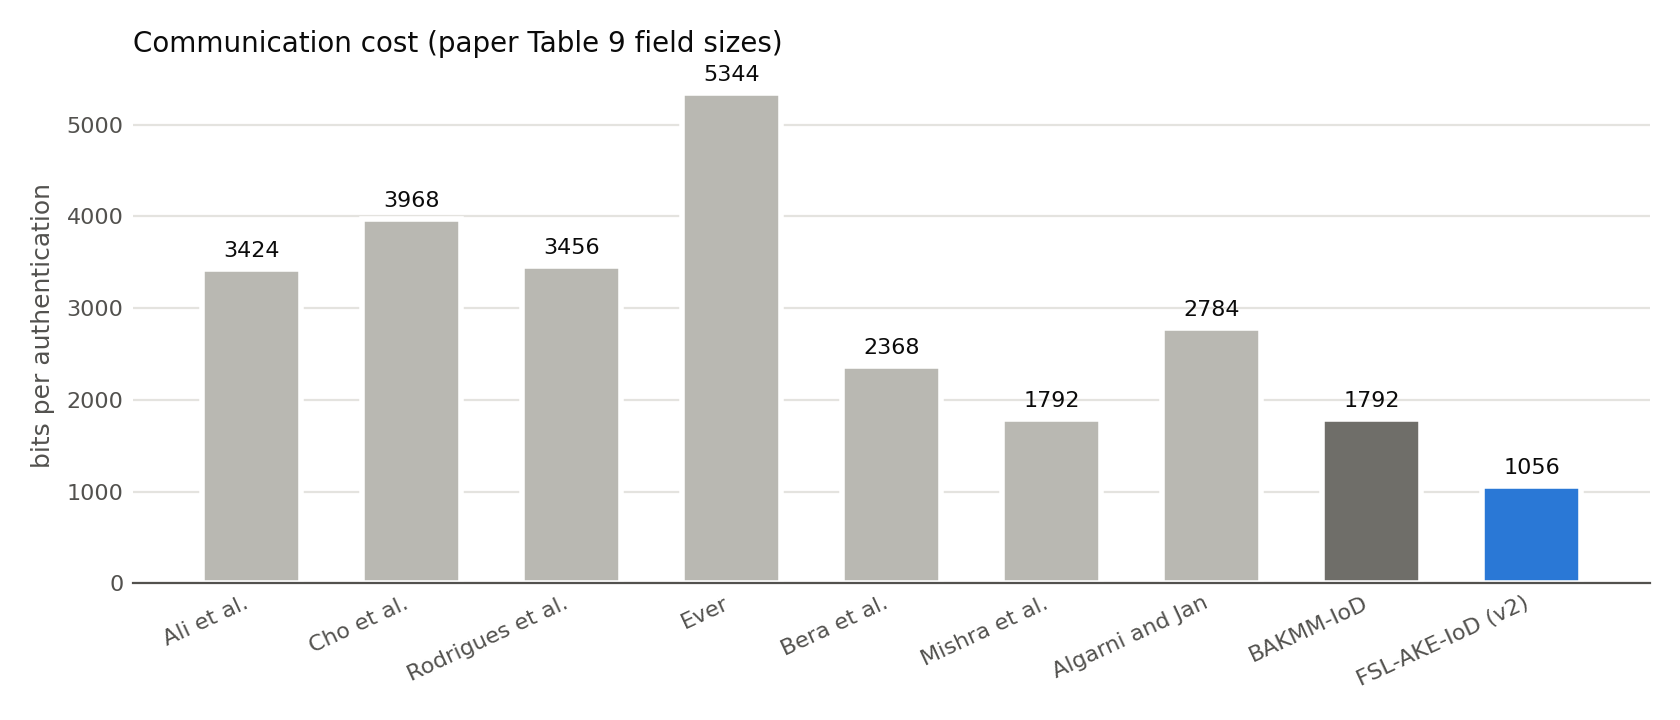

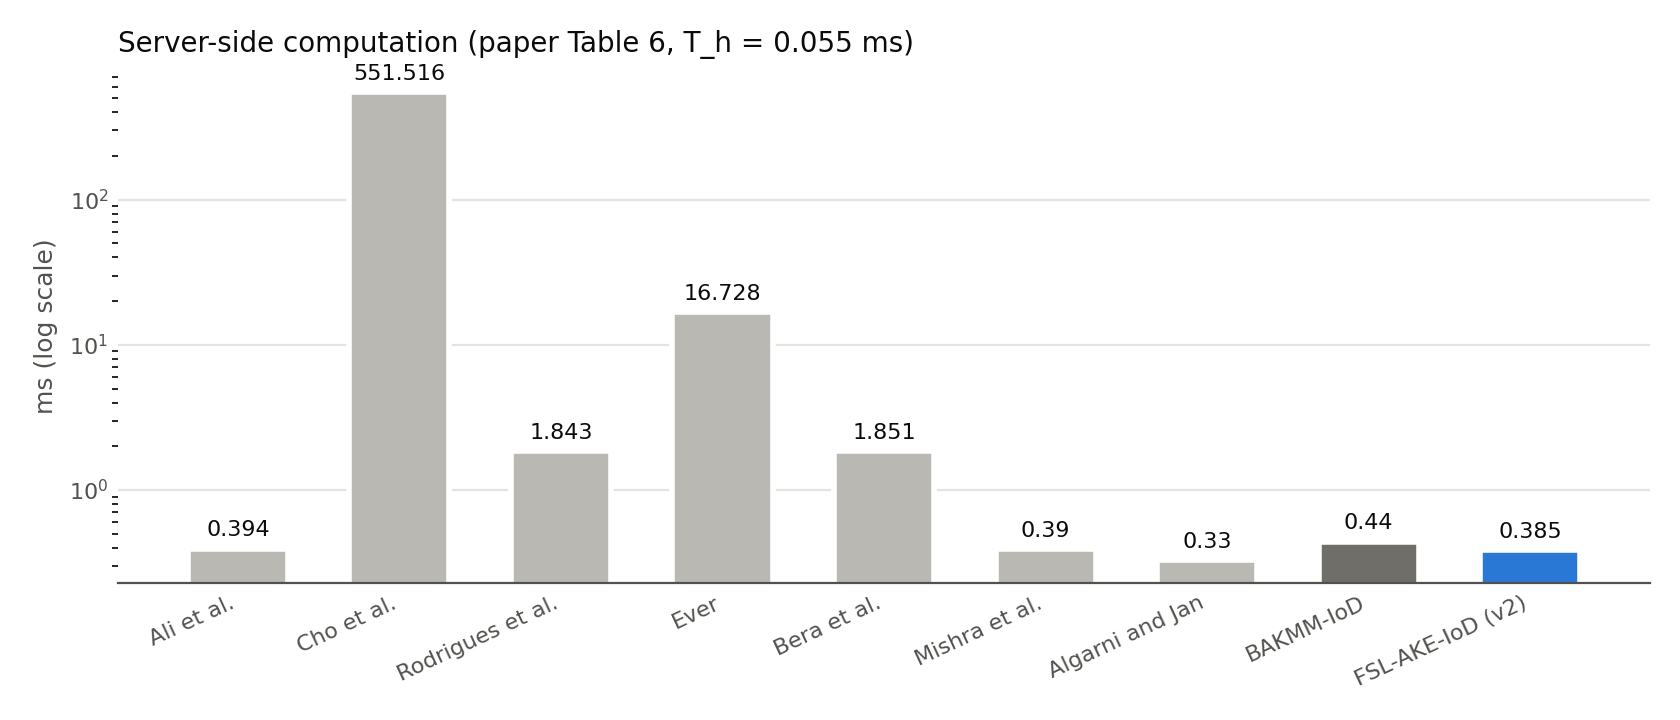

In [22]:
from IPython.display import Image, display
display(Image(filename="images/fslake_comm_cost.png", width=700))
display(Image(filename="images/fslake_server_cost.png", width=700))

**What we see:**
* **Drone:** 5 hashes (1.545 ms) against BAKMM-IoD's 8 (2.47 ms), 37.5 % less. This is the lowest of all nine schemes.
* **Communication:** 1056 bits in 2 messages against 1792 bits in 3, 41 % less. Also the lowest.
* **Server:** 7 hashes (0.385 ms) against 8. This is cheaper than BAKMM-IoD, **but not the cheapest overall**:
  Algarni & Jan need only 6 hashes (0.33 ms). We had written "cheaper in both computation and communication" in our
  draft; that is only true against BAKMM-IoD, so we corrected it.

## 12. Formal verification status, summary of all work, next steps

### Formal verification
We wrote models for the protocol checkers **Scyther** and **ProVerif**:
* normal models of v2 (`fslake_auth.spdl`, `fslake_key_mgmt.spdl`);
* **capture models** that leak the drone's memory after the session. For BAKMM-IoD we expect the session key to be
  found; for v2 (which leaks only the *evolved* key) we expect it to stay secret. A control model leaks the
  un-evolved key, to show the model can detect a leak;
* ProVerif forward-secrecy queries (`proverif/*.pv`).

**These were NOT RUN** because neither tool is installed on this machine. They can be run with
`SCYTHER=/path/to/scyther-linux bash scripts/run_formal.sh`. The Python attacks above are the evidence we *did* run.
We also wrote a proof sketch in the Real-or-Random model (in `FSL-AKE-IoD-security_verification.ipynb`).

### Everything we did

| Phase | Work | Where |
|---|---|---|
| 0 | Read the paper from page images; compared every equation across the paper, the notebooks, the code and the models | `FSL-AKE-IoD-security_verification.ipynb` |
| 1 | Re-tested every BAKMM-IoD claim; confirmed A0–A4; **found A5**; confirmed the errata | `proposed/code/attacks_bakmm_ext.py` |
| 2 | 32 attacks against BAKMM-IoD (both readings), v1 and v2; broke v1; designed and tested fixes F1–F4 | `proposed/code/attacks_fslake.py`, `fslake.py` |
| 2 | Ablation: switched each piece off to prove it is needed | `proposed/code/ablation.py`, `FSL-AKE-IoD-ablation.ipynb` |
| 3 | Scyther and ProVerif models (written, not run), proof sketch | `*.spdl`, `proverif/`, `scripts/run_formal.sh` |
| 4 | Instrumented cost, real SHA-256 timings, comparison with 7 other schemes, charts | `proposed/code/cost.py`, `FSL-AKE-IoD-performance.ipynb` |
| 5 | Protocol notebook with diagrams, LaTeX write-up, 50 automated tests, log of every command | `FSL-AKE-IoD-proposed_protocol.ipynb`, `fslake_technical_analysis.tex`, `tests/`, `VERIFICATION_LOG.md` |

### Final summary
* **BAKMM-IoD:** efficient, but its secrets never change, so one captured drone exposes its whole history (A1), and one
  lost or altered message locks a drone out (A3, A5). Parts of the paper are misprinted (A0, E, C).
* **FSL-AKE-IoD v1:** the right ideas (key evolution, hidden pseudonyms, fallback record, replay cache, masked
  database), but fragile record-keeping at the ES that several attacks could turn into lock-outs.
* **FSL-AKE-IoD v2:** the same messages and cost, with safe record-keeping (F1–F4). It resists every attack we tried
  except those no hash-only protocol can resist. It is cheaper than BAKMM-IoD on the drone, on the server and on the
  network, but not the cheapest server of all compared schemes.

### Next steps
1. Install Scyther and ProVerif and run the prepared models (one script).
2. Decide whether to add the optional third message (better ES-side security, +288 bits) or retry pseudonyms (unlinkable retries, +3 ES hashes).
3. Get the PDFs of the related papers to fill the "to verify" cells of our comparison table.
4. Measure on a real Raspberry Pi instead of using the paper's per-hash timings.

## 13. Glossary

| Symbol / word | Meaning |
|---|---|
| DE, ES, CS, RA | drone, ground station server, cloud server, registration authority |
| TID | temporary identity (pseudonym) sent on the air |
| RID, TC, MS | BAKMM-IoD's static drone secrets: pseudo-identity, temporal credential, master secret shared with the ES |
| K | FSL-AKE-IoD's evolving key shared by drone and ES |
| X_ES, C | the ES master secret in its secure chip, and the masked key stored in the database |
| N1, N2 / T1, T2 | random nonces / timestamps |
| V1, V2 | check values that prove knowledge of K (drone) and of SK (ES) |
| ΔT | maximum accepted delay (2 s in our simulation) |
| anchor / candidate | the key the drone has proved it holds / new keys the ES has offered but not yet seen used |
| KCI | key-compromise impersonation: using a stolen key to impersonate the *other* side to the victim |
| ablation | switching off one component at a time to see what breaks |